In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
fake_df = pd.read_csv('../data/Fake.csv')
true_df = pd.read_csv('../data/True.csv')

print("Fake news shape:", fake_df.shape)
print("Real news shape:", true_df.shape)

Fake news shape: (23481, 4)
Real news shape: (21417, 4)


In [3]:
print("Fake news columns:", fake_df.columns.tolist())
print("\nReal news columns:", true_df.columns.tolist())

print("\nFake news sample:")
fake_df.head(3)

Fake news columns: ['title', 'text', 'subject', 'date']

Real news columns: ['title', 'text', 'subject', 'date']

Fake news sample:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"


In [4]:
print("Missing values in Fake:")
print(fake_df.isnull().sum())

print("\nMissing values in Real:")
print(true_df.isnull().sum())

print("\nDuplicates in Fake:", fake_df.duplicated().sum())
print("Duplicates in Real:", true_df.duplicated().sum())

Missing values in Fake:
title      0
text       0
subject    0
date       0
dtype: int64

Missing values in Real:
title      0
text       0
subject    0
date       0
dtype: int64

Duplicates in Fake: 3
Duplicates in Real: 206


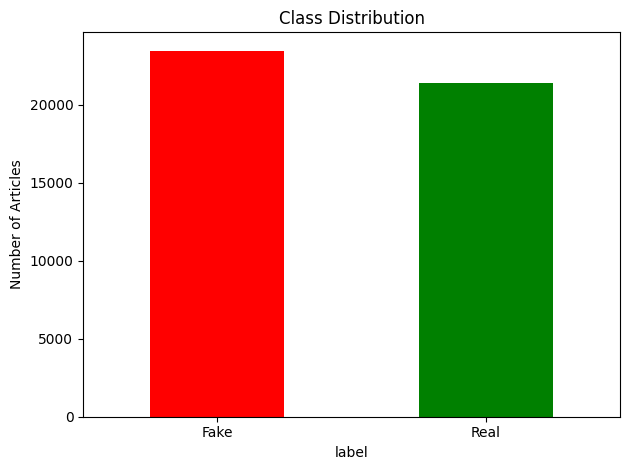

Total articles: 44898


In [5]:
fake_df['label'] = 0
true_df['label'] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)

df['label'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.xticks([0, 1], ['Fake', 'Real'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

print("Total articles:", len(df))

Average article length (words):
label
Fake    423.197905
Real    385.640099
Name: text_length, dtype: float64


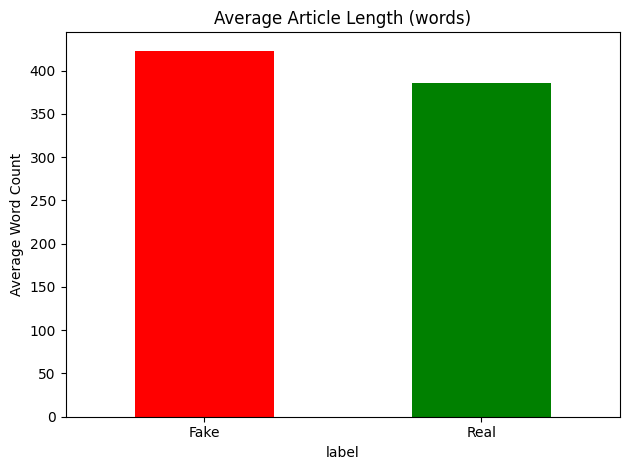

In [6]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

print("Average article length (words):")
print(df.groupby('label')['text_length'].mean().rename({0: 'Fake', 1: 'Real'}))

df.groupby('label')['text_length'].mean().plot(kind='bar', color=['red', 'green'])
plt.xticks([0, 1], ['Fake', 'Real'], rotation=0)
plt.title('Average Article Length (words)')
plt.ylabel('Average Word Count')
plt.tight_layout()
plt.show()